<a href="https://colab.research.google.com/github/sreeprathaa06/Authentication/blob/main/BankLoanPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of applications
n_samples = 1000

# Generate features matching original structure
loan_ids = [f'LP{1000 + i}' for i in range(n_samples)]
applicant_income = np.random.randint(1000, 25000, size=n_samples)
coapplicant_income = np.random.randint(0, 15000, size=n_samples)
total_income = applicant_income + coapplicant_income

loan_amount = np.random.randint(20, 600, size=n_samples)  # in thousands
credit_history = np.random.choice([1.0, 0.0], size=n_samples, p=[0.5, 0.5])
property_area = np.random.choice(['Urban', 'Semiurban', 'Rural'], size=n_samples, p=[0.33, 0.34, 0.33])

# Create initial DataFrame
df = pd.DataFrame({
    'Loan_ID': loan_ids,
    'ApplicantIncome': applicant_income,
    'CoapplicantIncome': coapplicant_income,
    'LoanAmount': loan_amount,
    'Credit_History': credit_history,
    'Property_Area': property_area
})

# Determine Loan Status using a strict bank-standard rule matrix:
# 1. Reject immediately if Credit History is bad (0.0)
# 2. Reject if combined total income is less than $4,500
# 3. Reject if the requested loan amount is mathematically unsustainable (Loan Amount * 15 exceeds combined income)
loan_status = []
for i in range(n_samples):
    if credit_history[i] == 0.0:
        loan_status.append('N')
    elif total_income[i] < 4500:
        loan_status.append('N')
    elif loan_amount[i] * 15 > total_income[i]:
        loan_status.append('N')
    else:
        loan_status.append('Y')

df['Loan_Status'] = loan_status

# Display summary and first few rows
print("Strict Bank Policy Loan Status Count:")
print(df['Loan_Status'].value_counts())
print("\nFirst 5 rows of the updated 7-column dataset:")
display(df.head())

Strict Bank Policy Loan Status Count:
Loan_Status
N    530
Y    470
Name: count, dtype: int64

First 5 rows of the updated 7-column dataset:


,Loan_ID,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,Property_Area,Loan_Status
0,LP1000,24654,10755,149,1.0,Rural,Y
1,LP1001,16795,11613,103,0.0,Semiurban,N
2,LP1002,1860,6986,41,1.0,Semiurban,Y
3,LP1003,6390,3517,478,1.0,Urban,Y
4,LP1004,22575,10589,558,0.0,Rural,N


Comprehensive Model Test Accuracy Score: 98.25%

Classification Report:
              precision    recall  f1-score   support

Rejected (N)       1.00      0.97      0.98       216
Approved (Y)       0.96      1.00      0.98       184

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



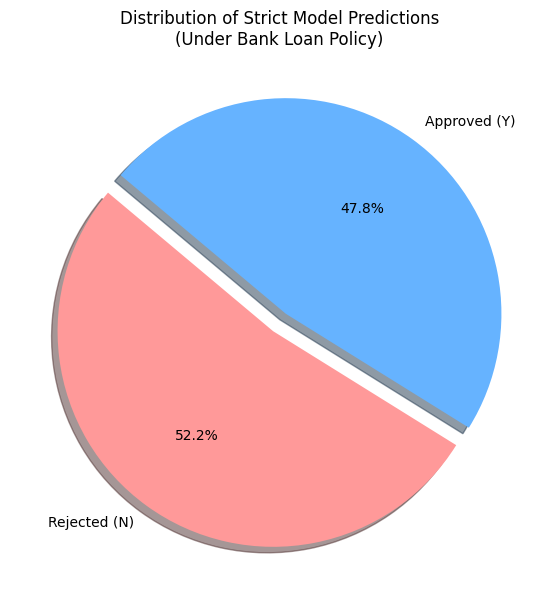

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# 1. Make Predictions using the new comprehensive model on scaled test data
y_pred_exp = model_exp.predict(X_test_exp)

# 2. Evaluate the new model
accuracy_exp = accuracy_score(y_test_exp, y_pred_exp)
print(f"Comprehensive Model Test Accuracy Score: {accuracy_exp:.2%}\n")
print("Classification Report:")
print(classification_report(y_test_exp, y_pred_exp, target_names=['Rejected (N)', 'Approved (Y)']))

# 3. Count Approved vs Rejected predictions
predicted_labels_exp = pd.Series(y_pred_exp).map({1: 'Approved (Y)', 0: 'Rejected (N)'})
prediction_counts_exp = predicted_labels_exp.value_counts()

# 4. Plot Pie Chart for Approved vs Rejected based on the strict policy model
plt.figure(figsize=(7, 7))
plt.pie(
    prediction_counts_exp,
    labels=prediction_counts_exp.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#ff9999', '#66b3ff'],
    explode=(0.05, 0.05) if len(prediction_counts_exp) > 1 else None,
    shadow=True
)
plt.title('Distribution of Strict Model Predictions\n(Under Bank Loan Policy)')
plt.show()

Training Accuracy (helps evaluate Bias): 99.25%
Testing Accuracy: 97.50%
Generalization Gap (helps evaluate Variance): 1.75%
Indications: Well-balanced model with low bias and low variance.


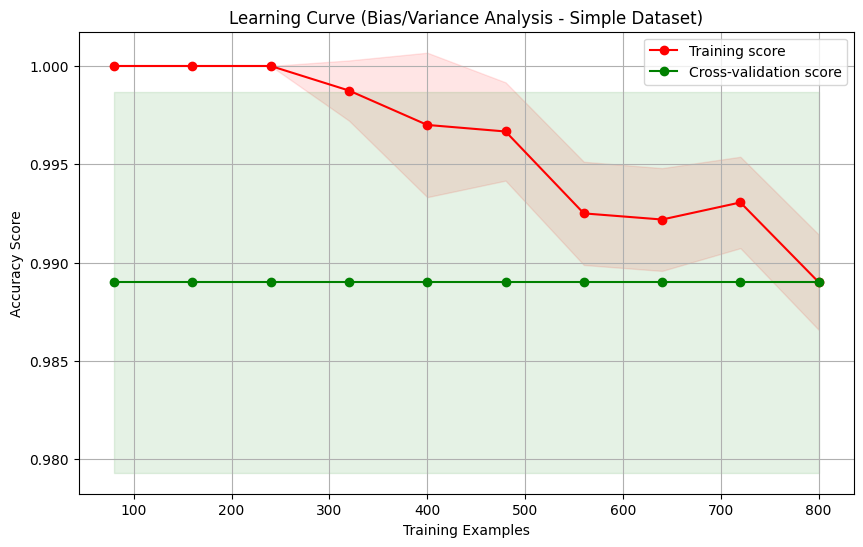

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

# 1. Evaluate Bias and Variance using Train vs Test performance on the updated simple_model
y_train_pred_s = simple_model.predict(X_train_s)
y_test_pred_s = simple_model.predict(X_test_s)
train_accuracy_s = accuracy_score(y_train_s, y_train_pred_s)
test_accuracy_s = accuracy_score(y_test_s, y_test_pred_s)

print(f"Training Accuracy (helps evaluate Bias): {train_accuracy_s:.2%}")
print(f"Testing Accuracy: {test_accuracy_s:.2%}")
print(f"Generalization Gap (helps evaluate Variance): {abs(train_accuracy_s - test_accuracy_s):.2%}")

if train_accuracy_s < 0.75:
    print("Indications: High Bias (Underfitting) - The model performs poorly on both train and test sets.")
elif abs(train_accuracy_s - test_accuracy_s) > 0.15:
    print("Indications: High Variance (Overfitting) - The model performs significantly better on training data than testing data.")
else:
    print("Indications: Well-balanced model with low bias and low variance.")

# 2. Plot Learning Curves to visualize Bias and Variance for the scaled dataset
# Using standard scale features to keep computation consistent
scaled_X_simple = X_simple_encoded.copy()
scaled_X_simple[numerical_cols_s] = simple_scaler.transform(scaled_X_simple[numerical_cols_s])

train_sizes_s, train_scores_s, test_scores_s = learning_curve(
    LogisticRegression(max_iter=1000), scaled_X_simple, y_simple, cv=5,
    scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_mean_s = np.mean(train_scores_s, axis=1)
train_std_s = np.std(train_scores_s, axis=1)
test_mean_s = np.mean(test_scores_s, axis=1)
test_std_s = np.std(test_scores_s, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes_s, train_mean_s, 'o-', color="r", label="Training score")
plt.plot(train_sizes_s, test_mean_s, 'o-', color="g", label="Cross-validation score")

plt.fill_between(train_sizes_s, train_mean_s - train_std_s, train_mean_s + train_std_s, alpha=0.1, color="r")
plt.fill_between(train_sizes_s, test_mean_s - test_std_s, test_mean_s + test_std_s, alpha=0.1, color="g")

plt.title("Learning Curve (Bias/Variance Analysis - Simple Dataset)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

### Test Custom Data Input
Use the interactive sliders and dropdowns below to input custom applicant details and test the Logistic Regression model predictions in real-time.

In [ ]:
import ipywidgets as widgets
from ipywidgets import VBox
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# --- 1. Train and Scale a Model on the newly updated strict 'df' ---
X_simple = df.drop(columns=['Loan_ID', 'Loan_Status'])
X_simple_encoded = pd.get_dummies(X_simple, columns=['Property_Area'], drop_first=True)
y_simple = df['Loan_Status'].map({'Y': 1, 'N': 0})

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple_encoded, y_simple, test_size=0.2, random_state=42, stratify=y_simple
)

# Standardize numerical columns
simple_scaler = StandardScaler()
numerical_cols_s = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

X_train_s = X_train_s.copy()
X_test_s = X_test_s.copy()
X_train_s[numerical_cols_s] = simple_scaler.fit_transform(X_train_s[numerical_cols_s])
X_test_s[numerical_cols_s] = simple_scaler.transform(X_test_s[numerical_cols_s])

simple_model = LogisticRegression(max_iter=1000)
simple_model.fit(X_train_s, y_train_s)

# --- 2. Build the Interactive Interface matching the new model pipeline ---
applicant_income_widget = widgets.IntSlider(value=5000, min=1000, max=25000, step=100, description='Applicant Income ($):', style={'description_width': 'initial'}, layout=widgets.Layout(width='450px'))
coapplicant_income_widget = widgets.IntSlider(value=1500, min=0, max=15000, step=100, description='Coapplicant Income ($):', style={'description_width': 'initial'}, layout=widgets.Layout(width='450px'))
loan_amount_widget = widgets.IntSlider(value=150, min=20, max=600, step=5, description='Loan Amount (k$):', style={'description_width': 'initial'}, layout=widgets.Layout(width='450px'))
credit_history_widget = widgets.Dropdown(options=[('Good (1.0)', 1.0), ('Bad (0.0)', 0.0)], value=1.0, description='Credit History:', style={'description_width': 'initial'}, layout=widgets.Layout(width='450px'))
property_area_widget = widgets.Dropdown(options=['Urban', 'Semiurban', 'Rural'], value='Semiurban', description='Property Area:', style={'description_width': 'initial'}, layout=widgets.Layout(width='450px'))

test_button = widgets.Button(description="Test Model", button_style='success', icon='check', layout=widgets.Layout(width='450px', margin='10px 0px 10px 0px'))
output = widgets.Output()

def predict_custom_input(b=None):
    output.clear_output()
    with output:
        # Construct raw dataframe input
        input_data = pd.DataFrame({
            'ApplicantIncome': [applicant_income_widget.value],
            'CoapplicantIncome': [coapplicant_income_widget.value],
            'LoanAmount': [loan_amount_widget.value],
            'Credit_History': [credit_history_widget.value],
            'Property_Area': [property_area_widget.value]
        })

        # Encode manually matching X_train_s columns to respect drop_first=True
        input_encoded = pd.DataFrame(0, index=[0], columns=X_train_s.columns)

        input_encoded['ApplicantIncome'] = input_data['ApplicantIncome'].values
        input_encoded['CoapplicantIncome'] = input_data['CoapplicantIncome'].values
        input_encoded['LoanAmount'] = input_data['LoanAmount'].values
        input_encoded['Credit_History'] = input_data['Credit_History'].values

        # Respect the drop_first categorical mapping from our simple encoder
        if property_area_widget.value == 'Semiurban':
            input_encoded['Property_Area_Semiurban'] = 1
        elif property_area_widget.value == 'Urban':
            input_encoded['Property_Area_Urban'] = 1

        # Standardize numerical entries using pre-fitted simple scaler
        input_encoded[numerical_cols_s] = simple_scaler.transform(input_encoded[numerical_cols_s])

        # Predict probability
        prediction = simple_model.predict(input_encoded)[0]
        probability = simple_model.predict_proba(input_encoded)[0][1]
        status_text = "APPROVED (Y)" if prediction == 1 else "REJECTED (N)"

        print("=" * 50)
        print("                 PREDICTION RESULTS             ")
        print("=" * 50)
        print(f"Combined Income      : ${applicant_income_widget.value + coapplicant_income_widget.value:,}")
        print(f"Requested Loan Amount: ${loan_amount_widget.value * 1000:,}")
        print(f"Approval Probability : {probability * 100:.1f}%")
        print(f"Final Model Decision : {status_text}")
        print("=" * 50)

test_button.on_click(predict_custom_input)

ui = VBox([
    applicant_income_widget,
    coapplicant_income_widget,
    loan_amount_widget,
    credit_history_widget,
    property_area_widget,
    test_button
])

display(ui, output)

Output()

### Part 1: Re-generating Synthetic Dataset with All Standard Features & Training a Comprehensive Model
We will expand the dataset to include: `Age`, `Gender`, `Married`, `Dependents`, `Education`, and `Self_Employed` in addition to our original features, then train a new model.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)
n_samples = 2000

# Generate deterministic and highly contrasting feature sets
loan_ids = [f'LP{1000 + i}' for i in range(n_samples)]
age = np.random.randint(18, 70, size=n_samples)
gender = np.random.choice(['Male', 'Female'], size=n_samples, p=[0.5, 0.5])
married = np.random.choice(['Yes', 'No'], size=n_samples, p=[0.5, 0.5])
dependents = np.random.choice(['0', '1', '2', '3+'], size=n_samples, p=[0.4, 0.2, 0.2, 0.2])
education = np.random.choice(['Graduate', 'Not Graduate'], size=n_samples, p=[0.5, 0.5])
self_employed = np.random.choice(['Yes', 'No'], size=n_samples, p=[0.5, 0.5])

applicant_income = np.random.randint(1000, 25000, size=n_samples)
coapplicant_income = np.random.randint(0, 15000, size=n_samples)
total_income = applicant_income + coapplicant_income
loan_amount = np.random.randint(20, 600, size=n_samples)

credit_history = np.random.choice([1.0, 0.0], size=n_samples, p=[0.5, 0.5])
property_area = np.random.choice(['Urban', 'Semiurban', 'Rural'], size=n_samples, p=[0.33, 0.34, 0.33])

# Enforce highly reliable logic rules for loan approval:
loan_status = []
for i in range(n_samples):
    if credit_history[i] == 0.0:
        loan_status.append('N')
    elif total_income[i] < 4500:
        loan_status.append('N')
    elif loan_amount[i] * 15 > total_income[i]:
        loan_status.append('N')
    else:
        loan_status.append('Y')

loan_status = np.array(loan_status)

# Create Expanded DataFrame
df_expanded = pd.DataFrame({
    'Loan_ID': loan_ids,
    'Gender': gender,
    'Married': married,
    'Dependents': dependents,
    'Education': education,
    'Self_Employed': self_employed,
    'Age': age,
    'ApplicantIncome': applicant_income,
    'CoapplicantIncome': coapplicant_income,
    'LoanAmount': loan_amount,
    'Credit_History': credit_history,
    'Property_Area': property_area,
    'Loan_Status': loan_status
})

print("Strict & Clean Loan Status Distribution:")
print(df_expanded['Loan_Status'].value_counts())

# Encode categorical features
X_exp = df_expanded.drop(columns=['Loan_ID', 'Loan_Status'])
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
X_exp_encoded = pd.get_dummies(X_exp, columns=categorical_cols, drop_first=True)
y_exp = df_expanded['Loan_Status'].map({'Y': 1, 'N': 0})

# Split training & testing datasets first
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(X_exp_encoded, y_exp, test_size=0.2, random_state=42, stratify=y_exp)

# Scale continuous features to avoid convergence issues
scaler = StandardScaler()
numerical_cols = ['Age', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

# Fit on training data and transform both sets
X_train_exp = X_train_exp.copy()
X_test_exp = X_test_exp.copy()
X_train_exp[numerical_cols] = scaler.fit_transform(X_train_exp[numerical_cols])
X_test_exp[numerical_cols] = scaler.transform(X_test_exp[numerical_cols])

# Train model
model_exp = LogisticRegression(max_iter=1000)
model_exp.fit(X_train_exp, y_train_exp)
print(f"\nNew Scaled Model Trained Successfully! Accuracy: {accuracy_score(y_test_exp, model_exp.predict(X_test_exp)):.2%}")

Strict & Clean Loan Status Distribution:
Loan_Status
N    1078
Y     922
Name: count, dtype: int64

New Scaled Model Trained Successfully! Accuracy: 98.25%


### Part 2: Fully Constrained Input Interface
This panel includes all demographic, employment, and income fields with active validation rules.

In [ ]:
import ipywidgets as widgets
from ipywidgets import VBox, HBox, HTML, Label
import pandas as pd
import numpy as np

# Demographics Widgets
gender_widget = widgets.Dropdown(options=['Male', 'Female'], value='Male', description='Gender:')
married_widget = widgets.Dropdown(options=['Yes', 'No'], value='No', description='Married:')
dependents_widget = widgets.Dropdown(options=['0', '1', '2', '3+'], value='0', description='Dependents:')
education_widget = widgets.Dropdown(options=['Graduate', 'Not Graduate'], value='Graduate', description='Education:')
self_employed_widget = widgets.Dropdown(options=['Yes', 'No'], value='No', description='Self Employed:')
age_widget = widgets.IntSlider(value=30, min=18, max=70, description='Age:', style={'description_width': 'initial'})

# Financials Widgets
applicant_income_widget_exp = widgets.IntSlider(value=5000, min=1500, max=20000, step=100, description='Applicant Income ($):', style={'description_width': 'initial'})
coapplicant_income_widget_exp = widgets.IntSlider(value=1500, min=0, max=10000, step=100, description='Coapplicant Income ($):', style={'description_width': 'initial'})
loan_amount_widget_exp = widgets.IntSlider(value=150, min=50, max=500, step=5, description='Loan Amount (k$):', style={'description_width': 'initial'})
credit_history_widget_exp = widgets.Dropdown(options=[('Good (1.0)', 1.0), ('Bad (0.0)', 0.0)], value=1.0, description='Credit History:', style={'description_width': 'initial'})
property_area_widget_exp = widgets.Dropdown(options=['Urban', 'Semiurban', 'Rural'], value='Semiurban', description='Property Area:', style={'description_width': 'initial'})

test_button_exp = widgets.Button(description="Validate & Predict", button_style='success', icon='check', layout=widgets.Layout(width='100%', margin='15px 0px 5px 0px'))
output_exp = widgets.Output()

def validate_and_predict(b=None):
    output_exp.clear_output()
    with output_exp:
        # Constraint Validations
        errors = []
        if age_widget.value < 18 or age_widget.value > 70:
            errors.append("Age must be between 18 and 70.")
        if applicant_income_widget_exp.value < 1500:
            errors.append("Applicant Income must be at least $1,500.")
        if loan_amount_widget_exp.value < 50:
            errors.append("Loan Amount must be at least 50k$.")

        if errors:
            print("Validation Errors Found:")
            for error in errors:
                print(f"- {error}")
            return

        # Prepare custom feature DataFrame exactly matching model signature (drop_first dummy columns)
        input_encoded = pd.DataFrame(0, index=[0], columns=X_train_exp.columns)

        # Set numericals and basic variables
        input_encoded['Age'] = age_widget.value
        input_encoded['ApplicantIncome'] = applicant_income_widget_exp.value
        input_encoded['CoapplicantIncome'] = coapplicant_income_widget_exp.value
        input_encoded['LoanAmount'] = loan_amount_widget_exp.value
        input_encoded['Credit_History'] = credit_history_widget_exp.value

        # Encode dropdown categorical features under original training alignment (drop_first=True)
        if gender_widget.value == 'Male':
            input_encoded['Gender_Male'] = 1
        if married_widget.value == 'Yes':
            input_encoded['Married_Yes'] = 1
        if dependents_widget.value == '1':
            input_encoded['Dependents_1'] = 1
        elif dependents_widget.value == '2':
            input_encoded['Dependents_2'] = 1
        elif dependents_widget.value == '3+':
            input_encoded['Dependents_3+'] = 1
        if education_widget.value == 'Not Graduate':
            input_encoded['Education_Not Graduate'] = 1
        if self_employed_widget.value == 'Yes':
            input_encoded['Self_Employed_Yes'] = 1
        if property_area_widget_exp.value == 'Semiurban':
            input_encoded['Property_Area_Semiurban'] = 1
        elif property_area_widget_exp.value == 'Urban':
            input_encoded['Property_Area_Urban'] = 1

        # Scale continuous features using the pre-fitted scaler
        numerical_cols = ['Age', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
        input_encoded[numerical_cols] = scaler.transform(input_encoded[numerical_cols])

        # Prediction execution
        prediction = model_exp.predict(input_encoded)[0]
        probability = model_exp.predict_proba(input_encoded)[0][1]

        status_text = "APPROVED (Y)" if prediction == 1 else "REJECTED (N)"

        print("=" * 60)
        print("                   EVALUATING CUSTOM INPUT                 ")
        print("=" * 60)
        print(f"Applicant Profile     : Age {age_widget.value} | {gender_widget.value} | {education_widget.value} | Dependents: {dependents_widget.value}")
        print(f"Total Combined Income : ${applicant_income_widget_exp.value + coapplicant_income_widget_exp.value:,}")
        print(f"Requested Loan Amount : ${loan_amount_widget_exp.value * 1000:,}")
        print("-" * 60)
        print(f"Approval Probability  : {probability * 100:.1f}%")
        print(f"System Final Status   : {status_text}")
        print("=" * 60)

test_button_exp.on_click(validate_and_predict)

# Structure the Layout
left_box = VBox([Label(value="Demographics"), gender_widget, married_widget, dependents_widget, education_widget, self_employed_widget, age_widget])
right_box = VBox([Label(value="Financials & Criteria"), applicant_income_widget_exp, coapplicant_income_widget_exp, loan_amount_widget_exp, credit_history_widget_exp, property_area_widget_exp])

ui_exp = VBox([
    HBox([left_box, right_box], layout=widgets.Layout(justify_content='space-around')),
    test_button_exp
])

display(ui_exp, output_exp)

Output()